# Superstore Marketing Campaign
**Context**- A superstore is planning for the year-end sale. They want to launch a new offer - gold membership, that gives a 20% discount on all purchases, for only 499 USD which is 999 USD on other days. It will be valid only for existing customers and the campaign through phone calls is currently being planned for them. The management feels that the best way to reduce the cost of the campaign is to make a predictive model which will classify customers who might purchase the offer.

**Objective** - The superstore wants to predict the likelihood of the customer giving a positive response and wants to identify the different factors which affect the customer's response. You need to analyze the data provided to identify these factors and then build a prediction model to predict whether a customer will give a positive response.

**Data Overview**: Total records (rows): 2240 Total variables (columns): 22 Data Types: 18 integer variables:
These include columns:
'Id', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Response', 'Complain'
 1 float variable: Income (with 24 missing values)
 3 categorical (object) variables: 'Education', 'Marital_Status', and 'Dt_Customer'
 Missing Values: Only the Income column has missing values, with 24 missing entries (about 1.07% of the data).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#to scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

#algorithms to use
from sklearn.linear_model import LogisticRegression

#Metrics to evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Read the data**

In [ ]:
import pandas as pd
import requests
from io import StringIO

orig_url="https://drive.google.com/file/d/1GS4kOWVTCKcexmFJE9eLwCudIAtg7Gqa/view?usp=drive_link" # share link to data set

file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text

csv_raw = StringIO(url)
df = pd.read_csv(csv_raw)
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.describe()

,Id,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Id,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df['Income'].fillna(df['Income'].mean(), inplace=True)
df.isnull().sum()

,0
Id,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
from datetime import datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
print(df['Dt_Customer'].head())
reference_date = df['Dt_Customer'].min()
print(f"Reference Date: {reference_date}")
df['Days_Since_Customer'] = (reference_date - df['Dt_Customer']).dt.days
print(df[['Dt_Customer', 'Days_Since_Customer']].head())
df['Days_Since_Customer'] = df['Days_Since_Customer'].astype(int)
print(df.dtypes)


0   2014-06-16
1   2014-06-15
2   2014-05-13
3   2014-11-05
4   2014-08-04
Name: Dt_Customer, dtype: datetime64[ns]
Reference Date: 2012-01-08 00:00:00
  Dt_Customer  Days_Since_Customer
0  2014-06-16                 -890
1  2014-06-15                 -889
2  2014-05-13                 -856
3  2014-11-05                -1032
4  2014-08-04                 -939
Id                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases               

In [ ]:
# Drop the Dt_Customer column
df.drop(columns=['Dt_Customer'], inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [ ]:
object_cols = df.select_dtypes(include=['object']).columns
print("Object columns:", object_cols)


Object columns: Index(['Education', 'Marital_Status'], dtype='object')


In [ ]:
for col in object_cols:
    df[col] = df[col].astype('category')

print("Updated data types:")
print(df.dtypes)

Updated data types:
Id                        int64
Year_Birth                int64
Education              category
Marital_Status         category
Income                  float64
Kidhome                   int64
Teenhome                  int64
Recency                   int64
MntWines                  int64
MntFruits                 int64
MntMeatProducts           int64
MntFishProducts           int64
MntSweetProducts          int64
MntGoldProds              int64
NumDealsPurchases         int64
NumWebPurchases           int64
NumCatalogPurchases       int64
NumStorePurchases         int64
NumWebVisitsMonth         int64
Response                  int64
Complain                  int64
Days_Since_Customer       int64
dtype: object


**Separate the numerical and categorical variables**

In [ ]:
num_cols= ['Id', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumStorePurchases','NumWebVisitsMonth', 'Response', 'Complain','Days_Since_Customer']
cat_cols=['Education', 'Marital_Status']

In [ ]:
df[num_cols].head()

,Id,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Days_Since_Customer
0,1826,1970,84835.0,0,0,0,189,104,379,111,...,218,1,4,4,6,6,1,1,0,-890
1,1,1961,57091.0,0,0,0,464,5,64,7,...,37,1,7,3,7,7,5,1,0,-889
2,10476,1958,67267.0,0,1,0,134,11,59,15,...,30,1,3,2,5,5,2,0,0,-856
3,1386,1967,32474.0,1,1,0,10,0,1,0,...,0,1,1,0,2,2,7,0,0,-1032
4,5371,1989,21474.0,1,0,0,6,16,24,11,...,34,2,3,1,2,2,7,1,0,-939


In [ ]:
df[num_cols].describe()

,Id,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Days_Since_Customer
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,44.021875,2.325000,4.084821,2.662054,5.790179,5.790179,5.316518,0.149107,0.009375,-550.956696
std,3246.662198,11.984069,25037.797168,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,52.167439,1.932238,2.778714,2.923101,3.250958,3.250958,2.426645,0.356274,0.096391,232.229893
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1063.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,3.000000,0.000000,0.000000,-722.250000
50%,5458.500000,1970.000000,51741.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,24.000000,2.000000,4.000000,2.000000,5.000000,5.000000,6.000000,0.000000,0.000000,-550.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,56.000000,3.000000,6.000000,4.000000,8.000000,8.000000,7.000000,0.000000,0.000000,-377.750000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,362.000000,15.000000,27.000000,28.000000,13.000000,13.000000,20.000000,1.000000,1.000000,0.000000


In [ ]:
df[cat_cols].head()

,Education,Marital_Status
0,Graduation,Divorced
1,Graduation,Single
2,Graduation,Married
3,Graduation,Together
4,Graduation,Single


In [ ]:
df[cat_cols].describe()

,Education,Marital_Status
count,2240,2240
unique,5,8
top,Graduation,Married
freq,1127,864


In [ ]:
df['Education'].unique()

['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
Categories (5, object): ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']

In [ ]:
df['Marital_Status'].unique()

['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO', 'Alone', 'Absurd']
Categories (8, object): ['Absurd', 'Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow',
                         'YOLO']

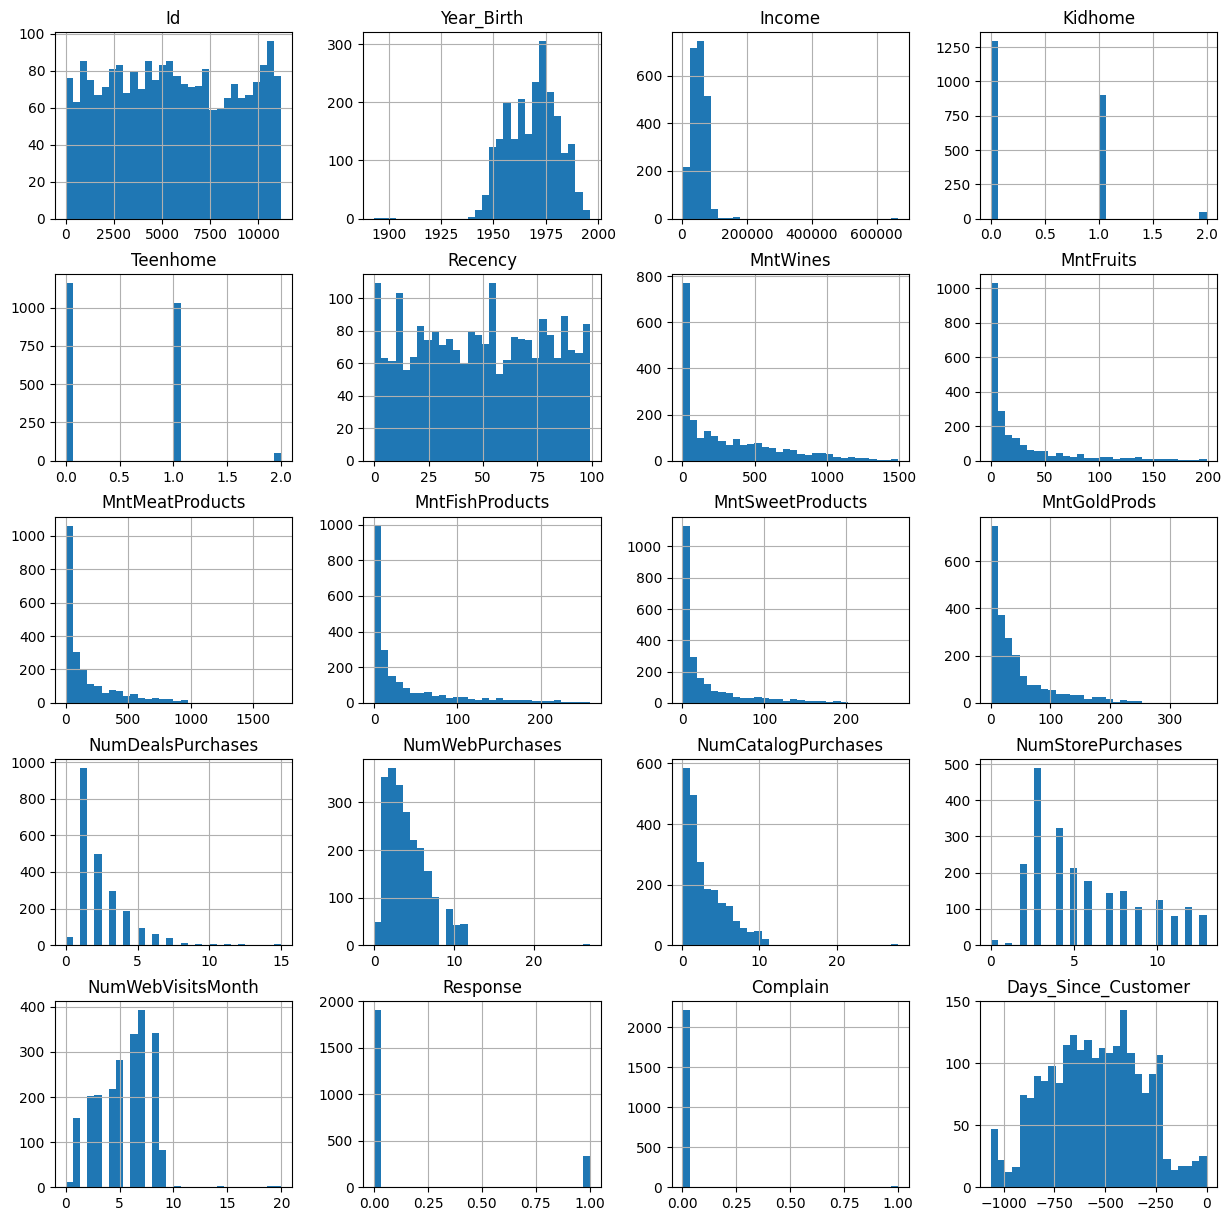

In [ ]:
df.hist(figsize=(15,15), bins=30)
plt.show()

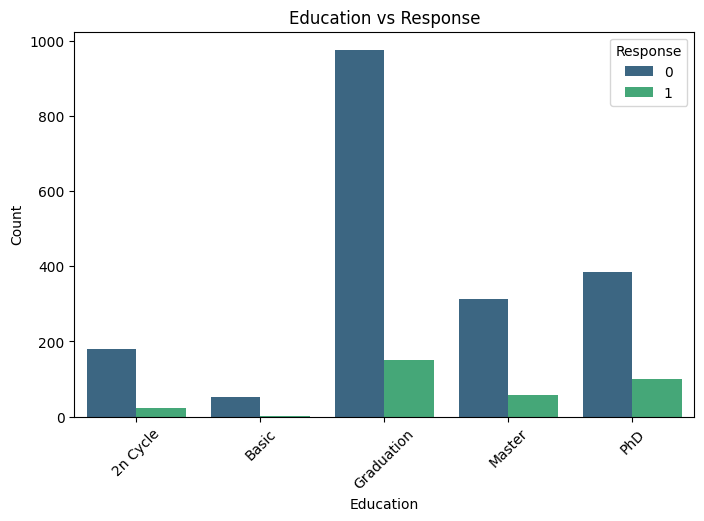

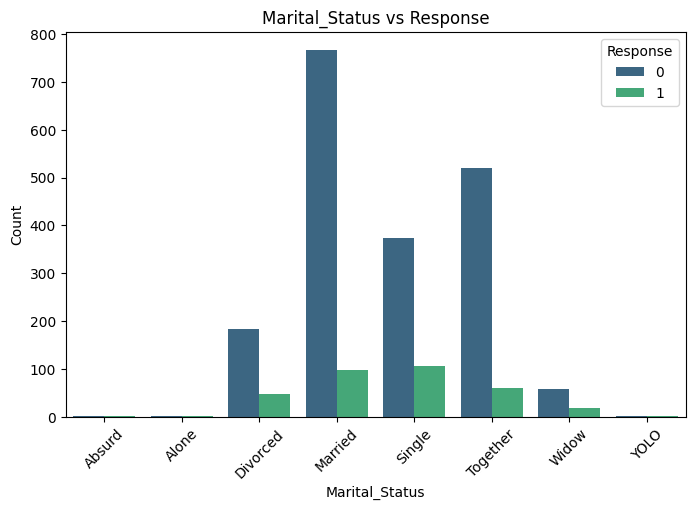

In [ ]:
# Visualization for categorical variables with proper y definition
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue=df['Response'], data=df, palette='viridis')
    plt.title(f"{col} vs Response")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Response")
    plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Id                   2240 non-null   int64   
 1   Year_Birth           2240 non-null   int64   
 2   Education            2240 non-null   category
 3   Marital_Status       2240 non-null   category
 4   Income               2240 non-null   float64 
 5   Kidhome              2240 non-null   int64   
 6   Teenhome             2240 non-null   int64   
 7   Recency              2240 non-null   int64   
 8   MntWines             2240 non-null   int64   
 9   MntFruits            2240 non-null   int64   
 10  MntMeatProducts      2240 non-null   int64   
 11  MntFishProducts      2240 non-null   int64   
 12  MntSweetProducts     2240 non-null   int64   
 13  MntGoldProds         2240 non-null   int64   
 14  NumDealsPurchases    2240 non-null   int64   
 15  NumWebPurchases      

In [ ]:
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Days_Since_Customer
0,1826,1970,Graduation,Divorced,84835.0,0,0,0,189,104,...,189,218,1,4,4,6,1,1,0,-890
1,1,1961,Graduation,Single,57091.0,0,0,0,464,5,...,0,37,1,7,3,7,5,1,0,-889
2,10476,1958,Graduation,Married,67267.0,0,1,0,134,11,...,2,30,1,3,2,5,2,0,0,-856
3,1386,1967,Graduation,Together,32474.0,1,1,0,10,0,...,0,0,1,1,0,2,7,0,0,-1032
4,5371,1989,Graduation,Single,21474.0,1,0,0,6,16,...,0,34,2,3,1,2,7,1,0,-939


In [ ]:
cat_cols

['Education', 'Marital_Status']

In [ ]:
cat_cols_dummies=['Education', 'Marital_Status']
df = pd.get_dummies(data = df, columns= cat_cols_dummies, drop_first= True)

**Feature Engineering**

In [ ]:
# Total Spending
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                           'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)




**Separate feature and target variables**

In [ ]:
y= df['Response']
X= df.drop(columns = ['Response'])

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Income                   2240 non-null   float64
 3   Kidhome                  2240 non-null   int64  
 4   Teenhome                 2240 non-null   int64  
 5   Recency                  2240 non-null   int64  
 6   MntWines                 2240 non-null   int64  
 7   MntFruits                2240 non-null   int64  
 8   MntMeatProducts          2240 non-null   int64  
 9   MntFishProducts          2240 non-null   int64  
 10  MntSweetProducts         2240 non-null   int64  
 11  MntGoldProds             2240 non-null   int64  
 12  NumDealsPurchases        2240 non-null   int64  
 13  NumWebPurchases          2240 non-null   int64  
 14  NumCatalogPurchases     

In [ ]:
# Check for missing values
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())


Missing values in X: 0
Missing values in y: 0


**Scaling the data**

In [ ]:
#Scaling the data
sc=StandardScaler()
X_scaled=sc.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
#splitting the data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=1,stratify=y)

In [ ]:
#creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Yes', 'No'], yticklabels=['Yes', 'No'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [ ]:
# Identify column types
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: ['Id', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Response', 'Complain', 'Days_Since_Customer', 'Total_Spending']
Categorical Columns: []


In [ ]:
# Set a correlation threshold (e.g., 0.9)
correlation_threshold = 0.9

# Compute the correlation matrix
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix to avoid duplicate pairs
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop (highly correlated columns)
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]

# Print columns to drop
print("Columns to drop due to high correlation:", to_drop)

# Drop the highly correlated columns from the dataset
df_cleaned = df.drop(columns=to_drop)

# Verify the new shape of the dataset
print("Shape of the dataset after dropping highly correlated columns:", df_cleaned.shape)


Columns to drop due to high correlation: []
Shape of the dataset after dropping highly correlated columns: (2240, 32)


**Correlation Matrix**

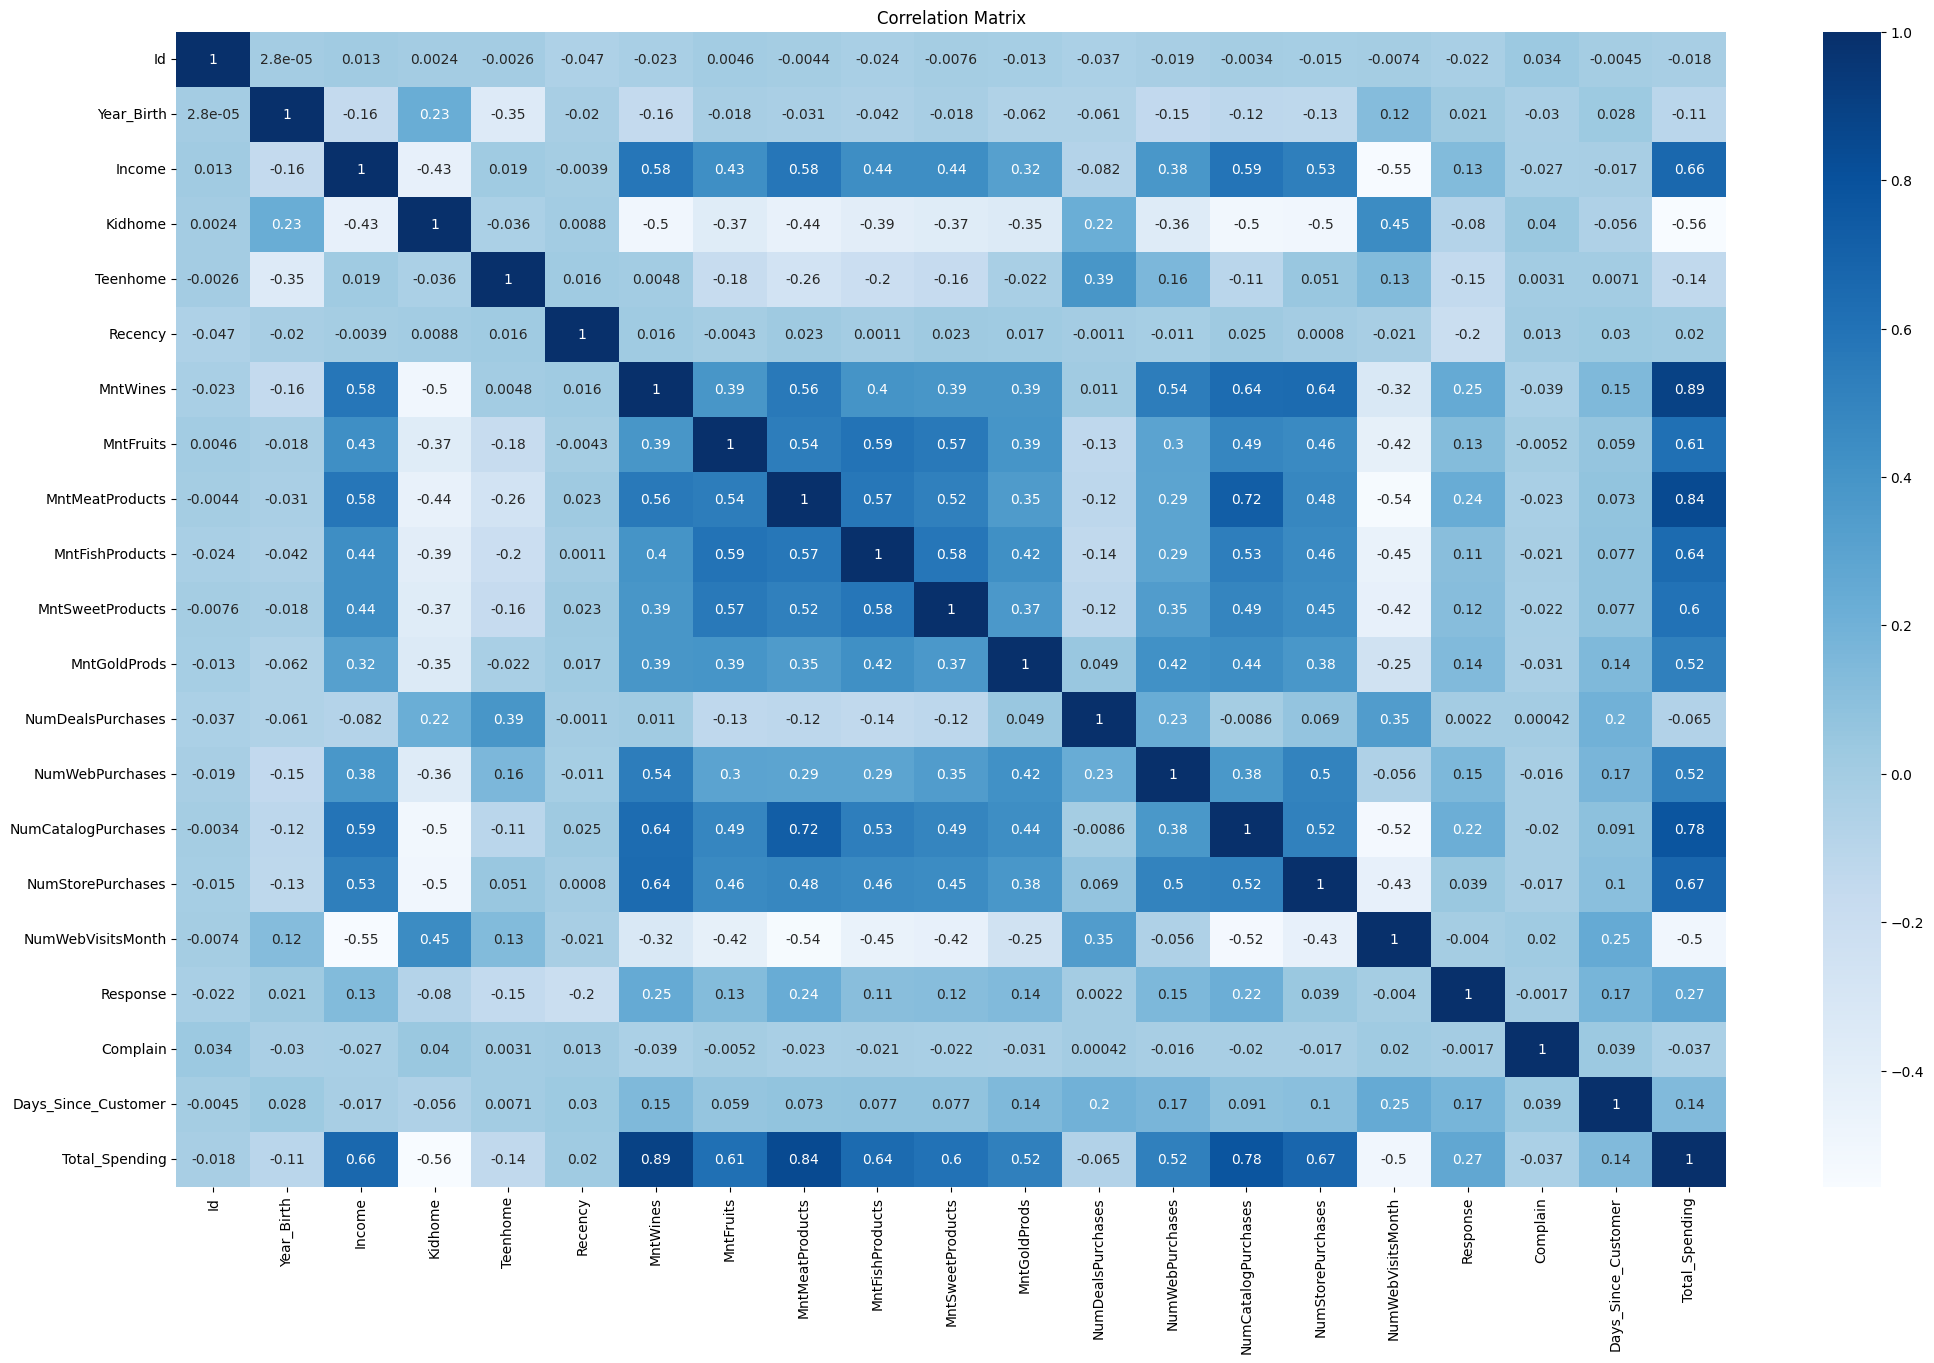

In [ ]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(25, 15))
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# Threshold for correlation
correlation_threshold = 0.9

# Compute the correlation matrix
corr_matrix = numerical_df.corr().abs()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find index of feature columns with correlation greater than the threshold
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]
df.drop(columns=to_drop, inplace=True)


**Logistic Regression**

In [ ]:
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1334
           1       0.59      0.27      0.37       234

    accuracy                           0.86      1568
   macro avg       0.74      0.62      0.65      1568
weighted avg       0.84      0.86      0.84      1568



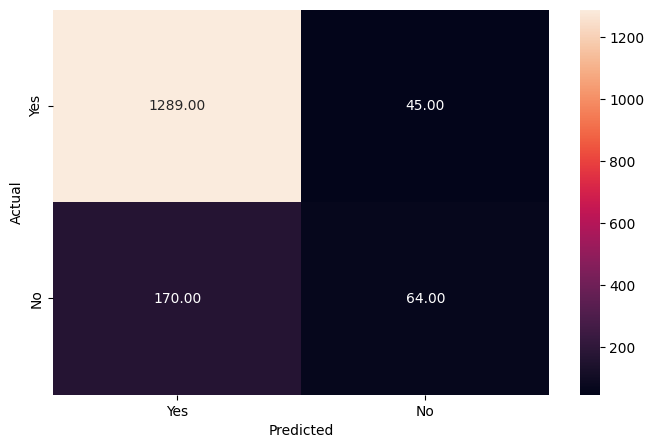

In [ ]:
y_pred_train = lg.predict(X_train)
metrics_score(y_train, y_pred_train)

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       572
           1       0.73      0.30      0.43       100

    accuracy                           0.88       672
   macro avg       0.81      0.64      0.68       672
weighted avg       0.87      0.88      0.86       672



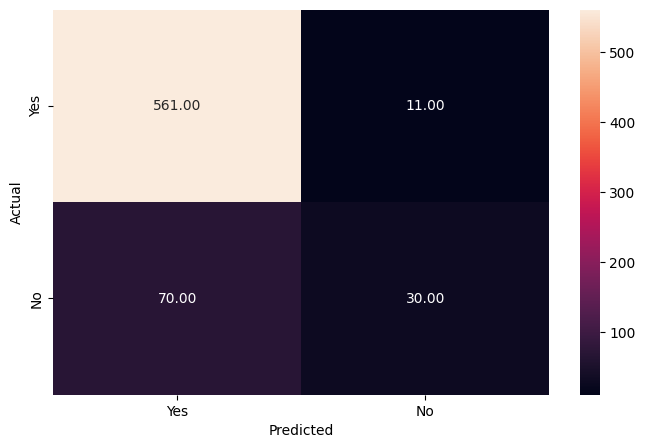

In [ ]:
y_pred_test = lg.predict(X_test)
metrics_score(y_test, y_pred_test)

In [ ]:
#printing the coefficients of logistic regression
cols=X.columns

coef_lg=lg.coef_

pd.DataFrame(coef_lg,columns=cols).T.sort_values(by=0,ascending=False)

# Convert the log odds to simple odds
odds = np.exp(lg.coef_[0]) #finding the odds

# adding the odds to a dataframe and sorting the values
pd.DataFrame(odds, X_train.columns, columns=['odds']).sort_values(by='odds', ascending=False)

,odds
Days_Since_Customer,1.578472
MntWines,1.442692
Total_Spending,1.387129
MntMeatProducts,1.373510
Education_PhD,1.366950
NumWebVisitsMonth,1.285195
MntGoldProds,1.242169
Kidhome,1.232023
NumCatalogPurchases,1.220128
NumWebPurchases,1.179732


**Precision-Recall curve**

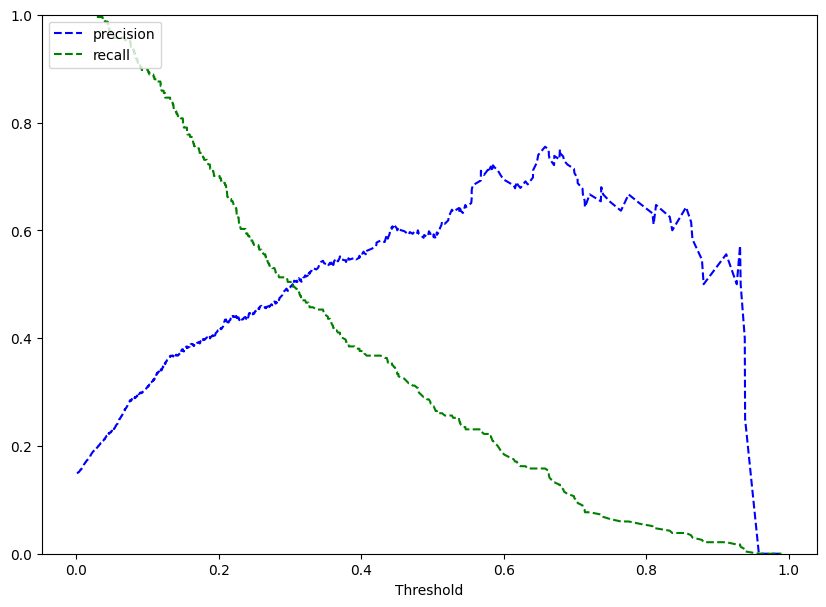

In [ ]:
y_scores_lg=lg.predict_proba(X_train) #predict_proba gives the probability of each observation belonging to each class


precisions_lg, recalls_lg, thresholds_lg = precision_recall_curve(y_train, y_scores_lg[:,1])

#Plot values of precisions, recalls, and thresholds
plt.figure(figsize=(10,7))
plt.plot(thresholds_lg, precisions_lg[:-1], 'b--', label='precision')
plt.plot(thresholds_lg, recalls_lg[:-1], 'g--', label = 'recall')
plt.xlabel('Threshold')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.show()

In [ ]:
y_scores_lg[:,1]

array([0.05578998, 0.30056833, 0.26840947, ..., 0.52222855, 0.02496295,
       0.21634367])

Inverse Relationship Between Precision and Recall:

As the threshold increases, precision improves, but recall declines. This is because the model becomes more selective, labeling fewer instances as positive (higher precision), but at the cost of missing true positives (lower recall).
Optimal Threshold Selection:

The optimal threshold depends on the business objective:
If minimizing false positives is more important (e.g., cost-sensitive applications), choose a higher threshold where precision is higher.
If minimizing false negatives is more critical (e.g., healthcare applications), choose a lower threshold where recall is higher.
Knee Point or Balance Point:

Around the intersection point of precision and recall, the threshold balances between the two metrics. This is a common choice for applications requiring a trade-off between false positives and false negatives.
Precision at Higher Thresholds:

At very high thresholds (close to 1), precision increases drastically, indicating fewer false positives but very low recall, as the model predicts only very confident positives.
Recall at Lower Thresholds:

At very low thresholds (close to 0), recall is maximized (close to 1), meaning the model identifies nearly all positives, but at the cost of reduced precision due to an increase in false positives.

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1334
           1       0.49      0.50      0.50       234

    accuracy                           0.85      1568
   macro avg       0.70      0.71      0.70      1568
weighted avg       0.85      0.85      0.85      1568



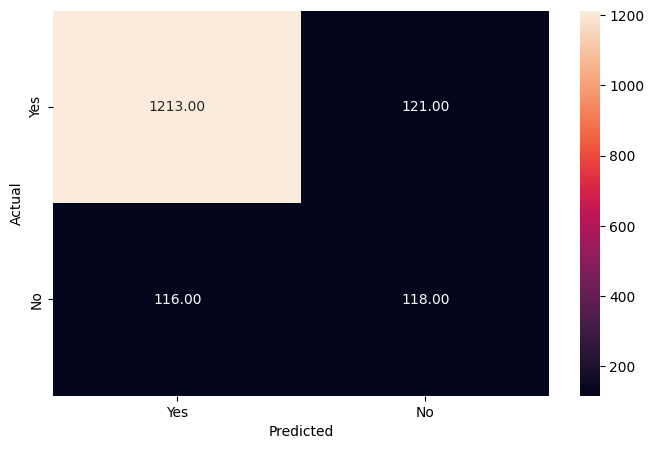

In [ ]:
optimal_threshold1=.30
y_pred_train = lg.predict_proba(X_train)
metrics_score(y_train, y_pred_train[:,1]>optimal_threshold1)

# **Obervations**
Precision for class 0: 91%, indicating most predictions for the negative class are accurate.
Precision for class 1: 49%, meaning nearly half of the positive predictions are false positives.
Recall for class 1: 50%, meaning half of the actual positive cases are being captured.
Weighted average metrics:
Accuracy: 85% (high overall accuracy driven by the dominant negative class).
F1-score: 85% for the weighted average, but only 50% for class 1.

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       572
           1       0.52      0.52      0.52       100

    accuracy                           0.86       672
   macro avg       0.72      0.72      0.72       672
weighted avg       0.86      0.86      0.86       672



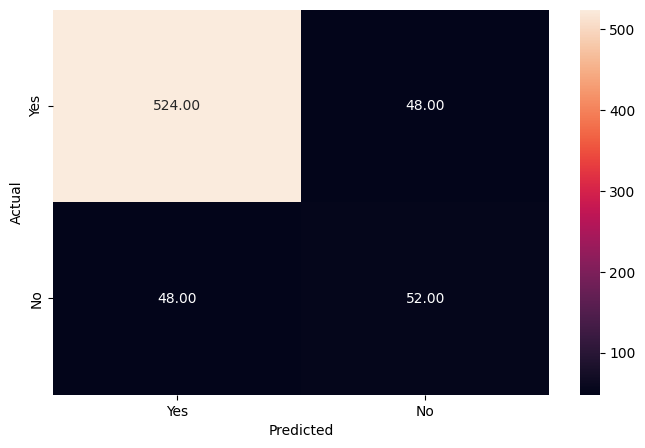

In [ ]:
optimal_threshold1=.30
y_pred_test = lg.predict_proba(X_test)
metrics_score(y_test, y_pred_test[:,1]>optimal_threshold1)

# **Observations**
True positives: 524 and true negatives: 52, showing strong predictive power for both classes.
False negatives and false positives are both 48, indicating some confusion between classes.

# **SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

# Assuming X_train and y_train are your original training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))
lg = LogisticRegression()
lg.fit(X_train_resampled, y_train_resampled)
y_pred_test = lg.predict(X_test)


Before SMOTE: Counter({0: 1334, 1: 234})
After SMOTE: Counter({0: 1334, 1: 1334})


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

Confusion Matrix:
 [[449 123]
 [ 22  78]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.78      0.86       572
           1       0.39      0.78      0.52       100

    accuracy                           0.78       672
   macro avg       0.67      0.78      0.69       672
weighted avg       0.87      0.78      0.81       672



The results from SMOTE indicate that the dataset is now balanced:

Before SMOTE:

Class 0 (Not Response): 1334
Class 1 (Response): 234
After SMOTE:

Both classes now have 1334 instances.

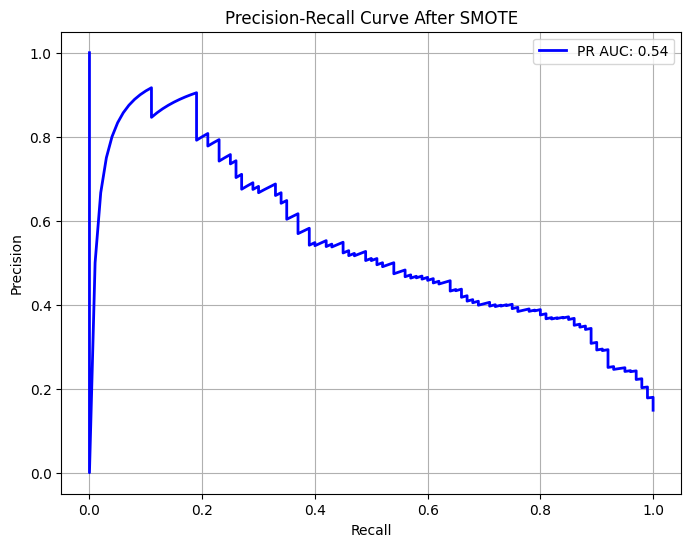

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
lg_smote = LogisticRegression(random_state=42)
lg_smote.fit(X_train_resampled, y_train_resampled)

# Step 2: Get predicted probabilities for the test set
y_pred_prob_smote = lg_smote.predict_proba(X_test)[:, 1]  # Probability for class 1 (Response)

# Step 3: Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_smote)

# Step 4: Calculate AUC for the PR curve
pr_auc = auc(recall, precision)

# Step 5: Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR AUC: {pr_auc:.2f}", color="blue", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve After SMOTE")
plt.legend()
plt.grid()
plt.show()


Precision at High Recall:
Before SMOTE: Precision drops off significantly as recall increases, indicating a poor balance between the two metrics when trying to capture more true positives.
After SMOTE: Precision is slightly better at higher recall values, showing that the synthetic balancing helps the model to generalize better when recall increases.
2. Overall Shape of the Curve:
Before SMOTE: The curve starts steeply but flattens quickly, indicating that the model struggles with balancing precision and recall for imbalanced data.
After SMOTE: The curve is more gradual and smoother, suggesting better performance in balancing the trade-off between precision and recall.
3. Precision-Recall AUC:
Before SMOTE: Likely lower PR AUC compared to after SMOTE due to the imbalance in the data.
After SMOTE: The PR AUC improves slightly (e.g., from 0.39 to 0.54 in the PR curve), showing that the model has better discriminatory ability after balancing the classes.
4. Threshold Behavior:
Before SMOTE: The threshold curve indicates significant imbalance sensitivity, with abrupt changes in precision and recall.
After SMOTE: The changes are more gradual and consistent, indicating that SMOTE reduces the sensitivity caused by class imbalance.
5. Impact on Business Metrics:
Before SMOTE: High false negatives (missed true positives) likely dominate, leading to potential missed opportunities in marketing campaigns.
After SMOTE: The balancing helps reduce false negatives, allowing for a more comprehensive capture of the positive class.

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       567
           1       0.58      0.17      0.26       105

    accuracy                           0.85       672
   macro avg       0.72      0.57      0.59       672
weighted avg       0.82      0.85      0.82       672



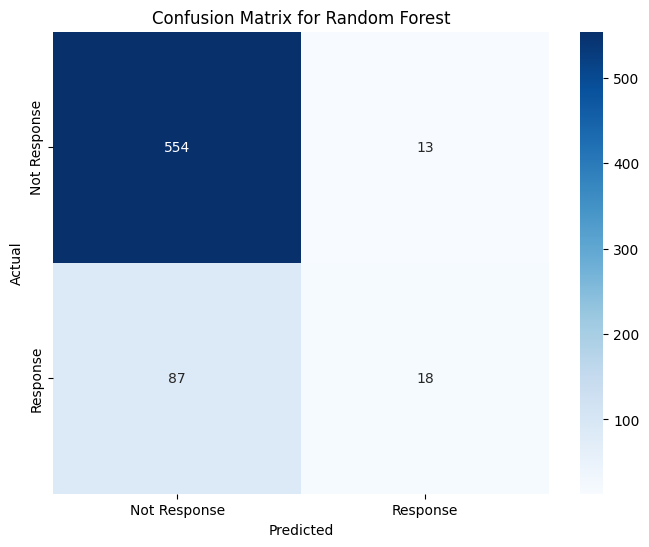

In [ ]:

# Split data into features (X) and target (y)
X = df.drop(columns=['Response'])  # Replace 'Response' with your target column name
y = df['Response']

# Split data into train-test sets (use the same splitting you used earlier for consistency)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Classification Report and Confusion Matrix
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Response', 'Response'], yticklabels=['Not Response', 'Response'])
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Accuracy: 85% – A good overall accuracy, but this is primarily driven by the model's strong performance on the majority class (0).
Macro Average:
Precision: 72%
Recall: 57%
F1-Score: 59% – Reflects that the model is significantly better at predicting the majority class compared to the minority class.

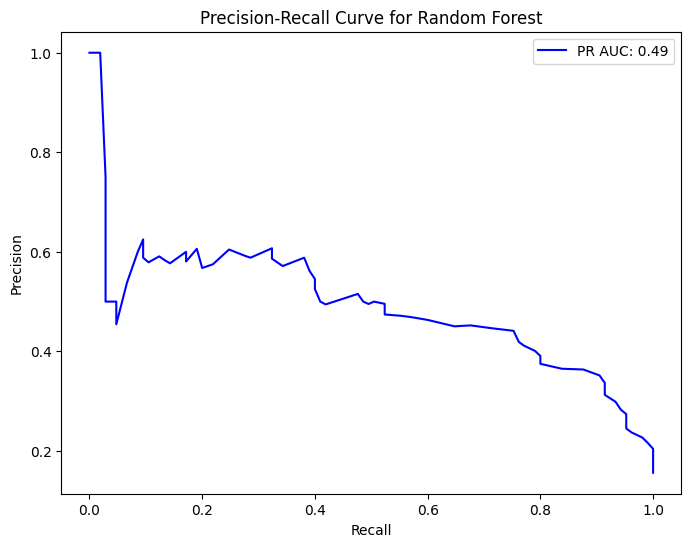

In [ ]:
# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_rf)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'PR AUC: {pr_auc:.2f}')
plt.title("Precision-Recall Curve for Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

At low recall (close to 0): Precision is high, nearing 1. This means when the model predicts positive, it is highly confident, but it does so for very few instances.
As recall increases: Precision starts to drop significantly, suggesting that the model begins to include more false positives in its predictions as it attempts to capture more true positives.

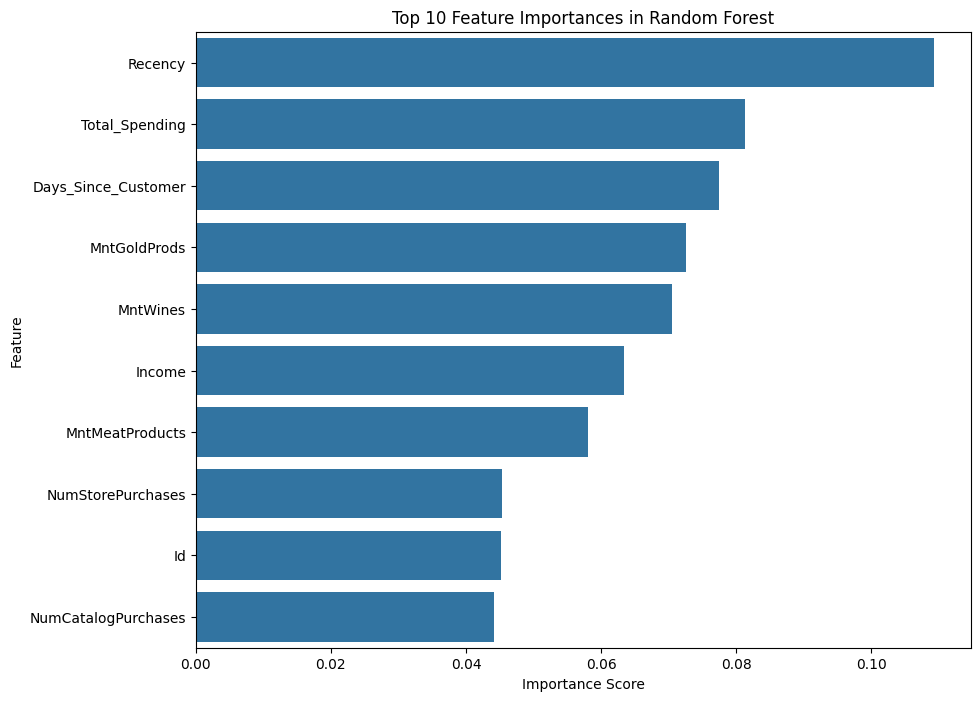

In [ ]:
# Feature Importance
feature_importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)
# Plot Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Feature Importances in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

MntGoldProds, MntWines, and MntMeatProducts are important predictors, indicating that the spending on specific product categories (gold products, wines, and meat products) has a significant role in predicting the target variable.
These features provide insights into customer preferences and spending behavior.

**Mean Residuals**

In [ ]:
print("Training features:", X_train.columns)
print("Testing features:", X_test.columns)


Training features: Index(['Id', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Days_Since_Customer',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO', 'Total_Spending'],
      dtype='object')
Testing features: Index(['Id', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisi

In [ ]:
X_test_aligned = X_test[X_train.columns]

In [ ]:
import numpy as np
y_pred_prob = lg.predict_proba(X_test)[:, 1]
# Calculate residuals (for regression or probability-based logistic regression predictions)
residuals = y_test - y_pred_prob  # Use y_pred for regression and y_pred_prob for logistic regression

# Check the mean of residuals
mean_residuals = np.mean(residuals)
print(f"Mean of residuals: {mean_residuals:.4f}")

Mean of residuals: -0.5260


In [ ]:
y_pred_prob

array([7.49583660e-156, 1.00000000e+000, 1.00000000e+000, 5.18016346e-056,
       1.00000000e+000, 2.04215916e-172, 2.37797997e-128, 0.00000000e+000,
       1.00000000e+000, 1.00000000e+000, 0.00000000e+000, 2.33278290e-164,
       1.00000000e+000, 5.82498713e-030, 5.87979273e-255, 1.00000000e+000,
       1.00000000e+000, 1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
       0.00000000e+000, 2.15163215e-004, 1.00000000e+000, 1.00000000e+000,
       1.00000000e+000, 6.74249677e-183, 1.00000000e+000, 1.00000000e+000,
       1.00000000e+000, 3.57105705e-170, 1.00000000e+000, 1.00000000e+000,
       1.00000000e+000, 1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
       1.26653466e-026, 1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
       1.00000000e+000, 1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
       1.00000000e+000, 3.25687471e-115, 2.63748604e-096, 1.00000000e+000,
       1.00000000e+000, 2.70780385e-296, 8.75726616e-170, 6.25731840e-008,
       1.00000000e+000, 3

In [ ]:
import numpy as np
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
# Calculate residuals (for regression or probability-based logistic regression predictions)
residuals = y_test - y_pred_prob  # Use y_pred for regression and y_pred_prob for logistic regression

# Check the mean of residuals
mean_residuals = np.mean(residuals)
print(f"Mean of residuals: {mean_residuals:.4f}")

Mean of residuals: 0.0034


**Observations**
The mean of residual is close to 0 for random forest method compared to logistic regression which makes it a more efficient model